# HLDA lambda threshold analysis

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from common.utils import collect_df
from common.hlda_utils import load_lambda_grid
from common.consts import res_colors
from common.plot_utils import scatter_with_labels, add_linear_fit
from paper.style_utils import set_paper_style

set_paper_style()

%config InlineBackend.figure_format = 'retina'


In [2]:
data_dir = repo_root / 'data'
mfpt_path = data_dir / 'mfpt-pace=25000-new-ref.pkl'
lambda_cache = data_dir / 'hlda_lambda_grid.pkl'

mfpt_all = pd.read_pickle(mfpt_path)
lambda_grid = load_lambda_grid(
    cache_path=lambda_cache,
    base_dir=data_dir / "traj",
    force=False,
)


In [3]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap='YlOrRd'):
    P = df.pivot(index='tF', columns='tU', values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading='flat'
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f'{val:.2f}', ha='center', va='center', fontsize=6)

    ax.set_xlabel('tU')
    ax.set_ylabel('tF')
    ax.set_title(title, fontsize=9)
    return im


In [4]:
mfpt_thresholds = sorted({float(k) for v in mfpt_all.values() for k in v.keys()})
unique_tf = sorted(lambda_grid['tF'].unique())
unique_tu = sorted(lambda_grid['tU'].unique())
skip_short = set()

metrics = [
    ('lambda', 'Lambda'),
    # ('delta_lambda', 'Delta lambda (mut - WT)'),
    ('abs_delta_lambda', 'Abs delta lambda'),
    # ('rel_delta_lambda', 'Delta lambda / lambda_WT'),
    # ('log_lambda_ratio', 'log(lambda / lambda_WT)'),
]

best_rows = []
best_cache = {}
heatmap_cache = {}


In [5]:
from scipy.stats import spearmanr, pearsonr
# Precompute lambda slices and threshold tables once to avoid repeated MFPT work.
lambda_by_pair = {}
for tF in unique_tf:
    for tU in unique_tu:
        if tU <= tF:
            continue
        sub_lam = lambda_grid[(lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
        if sub_lam.empty:
            continue
        lambda_by_pair[(float(tF), float(tU))] = sub_lam

df_thr_cache = {}
for thr in mfpt_thresholds:
    for (tF, tU), sub_lam in lambda_by_pair.items():
        df_thr = collect_df(
            mfpt_all,
            mfpt_threshold=float(thr),
            tF=float(tF),
            tU=float(tU),
            lambda_df=sub_lam,
            skip_short=skip_short,
            quiet=True,
        )
        wt_mfpt = float(df_thr.loc['WT', 'mfpt'])
        df_thr['log_mfpt_ratio'] = np.log(wt_mfpt / df_thr['mfpt'])
        wt_lambda = float(df_thr.loc['WT', 'lambda'])
        df_thr['delta_lambda'] = df_thr['lambda'] - wt_lambda
        df_thr['abs_delta_lambda'] = df_thr['delta_lambda'].abs()
        df_thr['rel_delta_lambda'] = df_thr['delta_lambda'] / wt_lambda
        df_thr['log_lambda_ratio'] = np.log(df_thr['lambda'] / wt_lambda)
        df_thr_cache[(float(thr), float(tF), float(tU))] = df_thr

for metric_key, metric_label in metrics:
    best = {'score': -np.inf}
    heatmap_rows = []
    for thr in mfpt_thresholds:
        rows = []
        for tF in unique_tf:
            for tU in unique_tu:
                if tU <= tF:
                    continue
                df_thr = df_thr_cache.get((float(thr), float(tF), float(tU)))
                if df_thr is None:
                    continue
                x = df_thr[metric_key]
                y = df_thr['log_mfpt_ratio']
                rho, p_rho = spearmanr(x, y, nan_policy='omit')
                pear, p_pear = pearsonr(x, y)
                score = np.nanmean([abs(rho), abs(pear)])
                rows.append({
                    'tF': float(tF),
                    'tU': float(tU),
                    'val': abs(rho),
                    'rho': abs(rho),
                    'rho_p': p_rho,
                    'pear': abs(pear),
                    'pear_p': p_pear,
                    'score': score,
                })
                if score > best['score']:
                    best = {
                        'metric': metric_key,
                        'metric_label': metric_label,
                        'thr': float(thr),
                        'tF': float(tF),
                        'tU': float(tU),
                        'val': abs(rho),
                        'rho': abs(rho),
                        'rho_p': p_rho,
                        'pear': abs(pear),
                        'pear_p': p_pear,
                        'score': score,
                    }
                    best_cache[metric_key] = df_thr
        heatmap_rows.append({'thr': float(thr), 'rows': rows})
    best_rows.append(best)
    heatmap_cache[metric_key] = heatmap_rows

best_df = pd.DataFrame(best_rows)
best_df


,metric,metric_label,thr,tF,tU,val,rho,rho_p,pear,pear_p,score
0,lambda,Lambda,0.36,0.25,0.57,0.65598,0.65598,0.000008,0.675371,0.000003,0.665675
1,abs_delta_lambda,Abs delta lambda,0.36,0.32,0.57,0.54065,0.54065,0.000458,0.560962,0.000249,0.550806


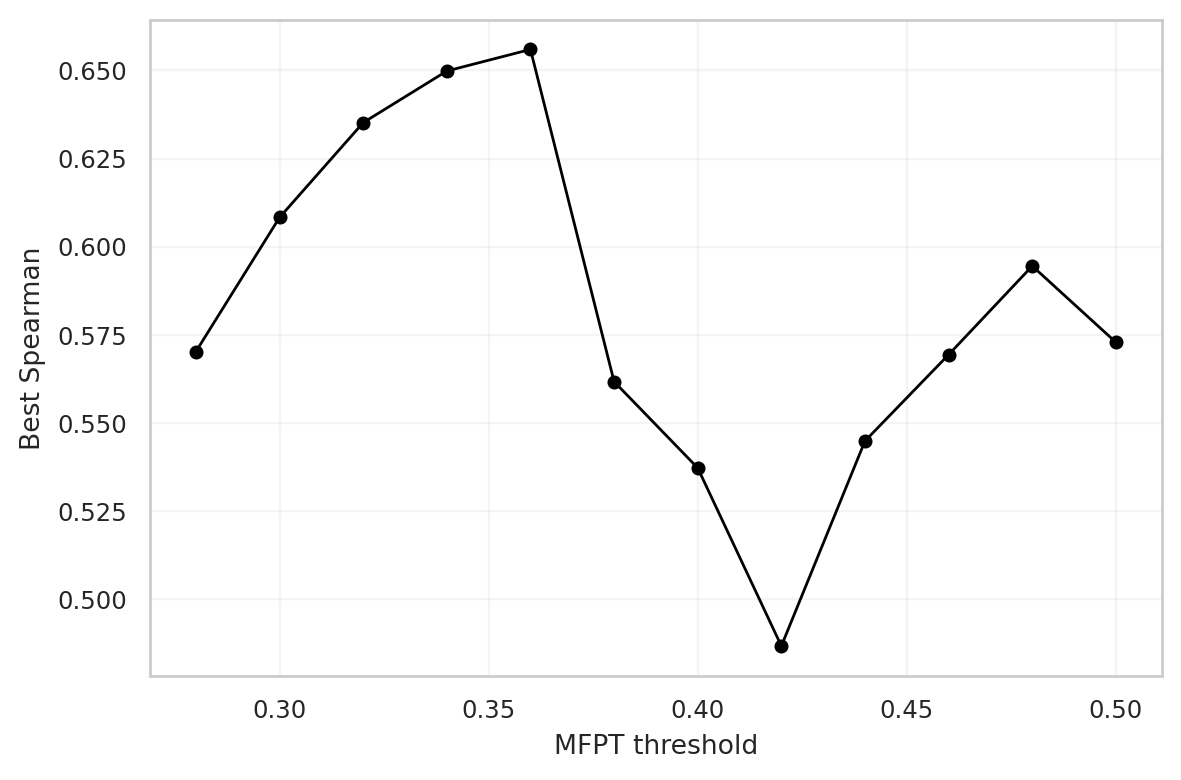

In [6]:
# Best Spearman per MFPT threshold (lambda metric only)
metric_key = 'lambda'
rows = []
for res in heatmap_cache[metric_key]:
    df = pd.DataFrame(res['rows'])
    if df.empty:
        continue
    best_val = df['rho'].max()
    rows.append({'thr': float(res['thr']), 'best_rho': float(best_val)})

plot_df = pd.DataFrame(rows).sort_values('thr')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(plot_df['thr'], plot_df['best_rho'], color='black', lw=1.0)
ax.scatter(plot_df['thr'], plot_df['best_rho'], color='black', s=18)
ax.set_xlabel('MFPT threshold')
ax.set_ylabel('Best Spearman')
# ax.set_title('Best Spearman vs MFPT threshold (lambda)')
ax.grid(alpha=0.2)
plt.tight_layout()


best subsample | thr=0.36, tF=0.25, tU=0.57 | rho=-0.88 | n=23


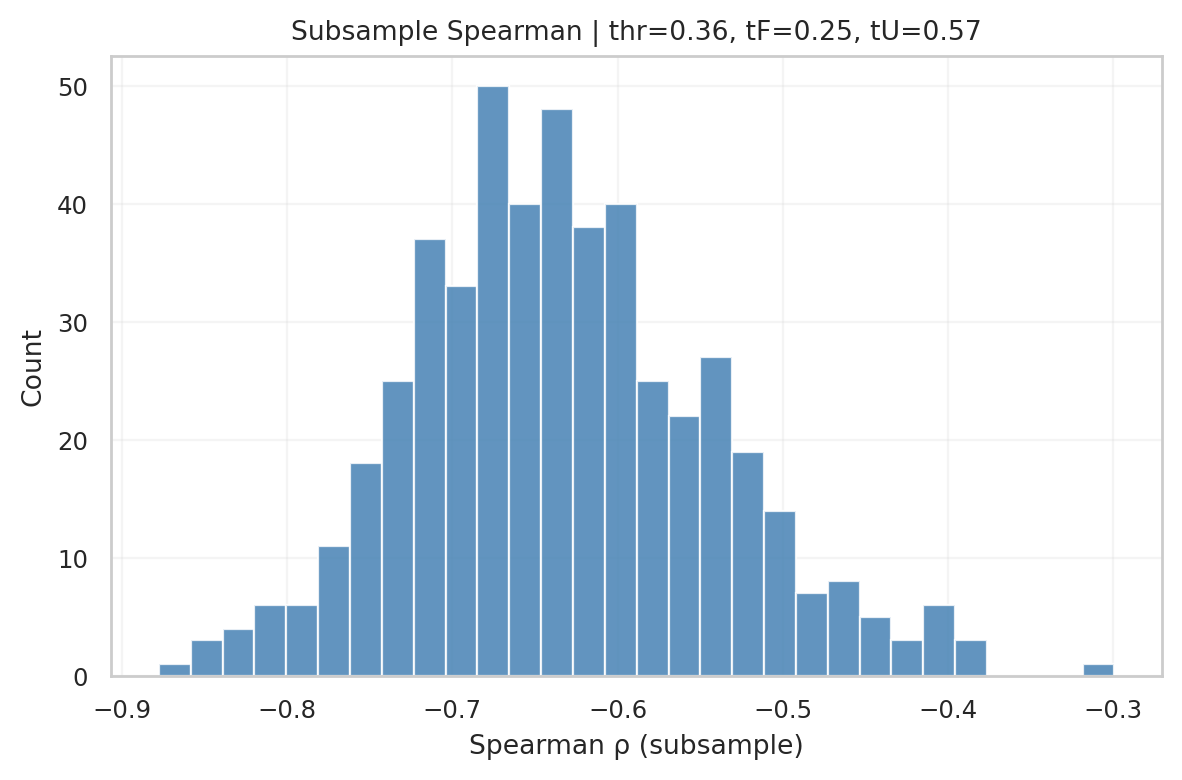

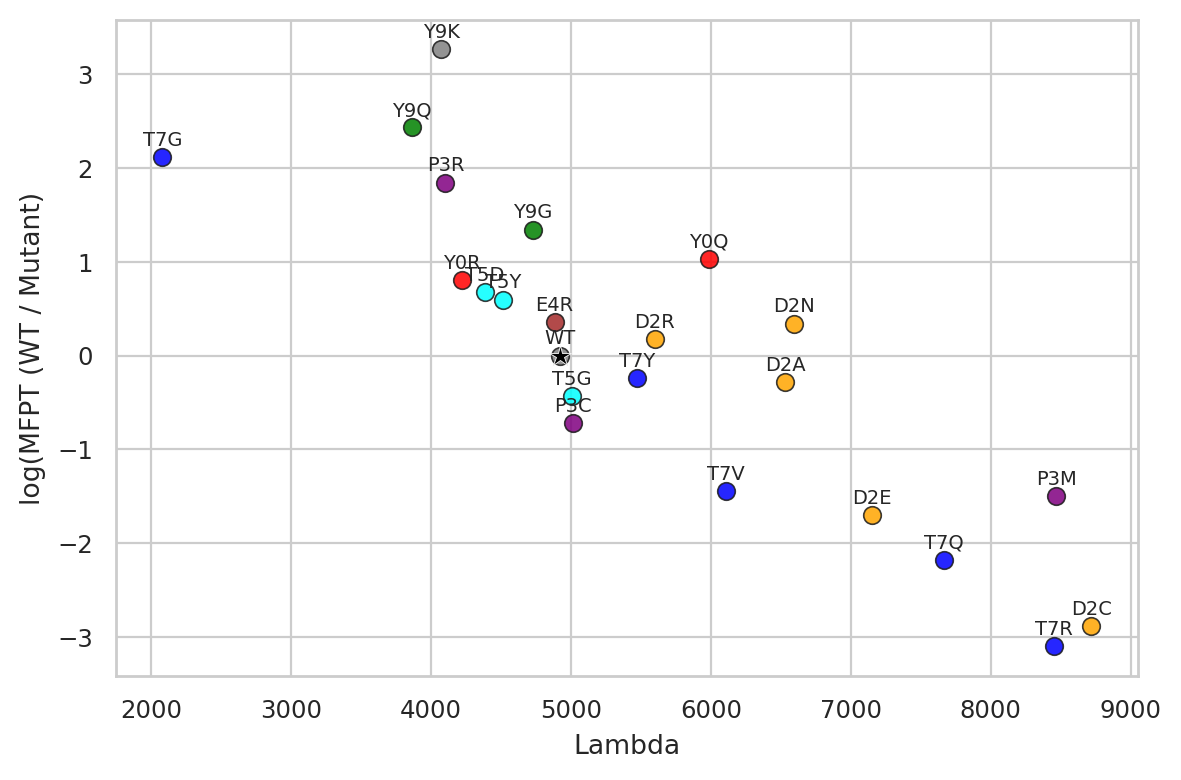

In [7]:
# Subsampling stability for the best MFPT threshold (lambda metric)
rng = np.random.default_rng(123)
metric_key = 'lambda'
row = best_df.loc[best_df['metric'] == metric_key].iloc[0]
thr = float(row['thr'])
tF = float(row['tF'])
tU = float(row['tU'])
df_best = df_thr_cache[(thr, tF, tU)].copy()

df_best = df_best.replace([np.inf, -np.inf], np.nan)
df_best = df_best.dropna(subset=[metric_key, 'log_mfpt_ratio'])

n = len(df_best)
n_sample = max(2, int(np.ceil(0.6 * n)))
n_iter = 500
spearman_vals = []
best_idx = None
best_rho = -np.inf

indices = df_best.index.tolist()
wt_present = 'WT' in indices
for _ in range(n_iter):
    if wt_present and n_sample > 1:
        rest = [i for i in indices if i != 'WT']
        pick = rng.choice(rest, size=n_sample - 1, replace=False)
        idx = ['WT'] + list(pick)
    else:
        idx = rng.choice(indices, size=n_sample, replace=False)
    sub = df_best.loc[idx]
    rho, _ = spearmanr(sub[metric_key], sub['log_mfpt_ratio'], nan_policy='omit')
    if np.isfinite(rho):
        spearman_vals.append(rho)
        if abs(rho) > best_rho:
            best_rho = abs(rho)
            best_idx = idx

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(spearman_vals, bins=30, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xlabel('Spearman ρ (subsample)')
ax.set_ylabel('Count')
ax.set_title(f'Subsample Spearman | thr={thr:.3g}, tF={tF:.2g}, tU={tU:.2g}')
ax.grid(alpha=0.2)
plt.tight_layout()

if best_idx is not None:
    best_sub = df_best.loc[best_idx]
    fig, ax = plt.subplots(figsize=(6, 4))
    scatter_with_labels(
        ax,
        best_sub,
        metric_key,
        'log_mfpt_ratio',
        label_col=None,
        color_col='residue_idx',
        colors=res_colors,
        s=40
    )
    if wt_present and 'WT' in best_sub.index:
        wt = best_sub.loc['WT']
        ax.plot(
            wt[metric_key],
            wt['log_mfpt_ratio'],
            marker='*',
            markersize=8,
            color='black',
            markeredgecolor='white',
            markeredgewidth=0.3,
            zorder=5,
        )
    ax.set_xlabel('Lambda')
    ax.set_ylabel('log(MFPT (WT / Mutant)')
    rho_best, _ = spearmanr(best_sub[metric_key], best_sub['log_mfpt_ratio'], nan_policy='omit')
    print(f'best subsample | thr={thr:.3g}, tF={tF:.2g}, tU={tU:.2g} | rho={rho_best:.2g} | n={len(best_sub)}')
    plt.tight_layout()


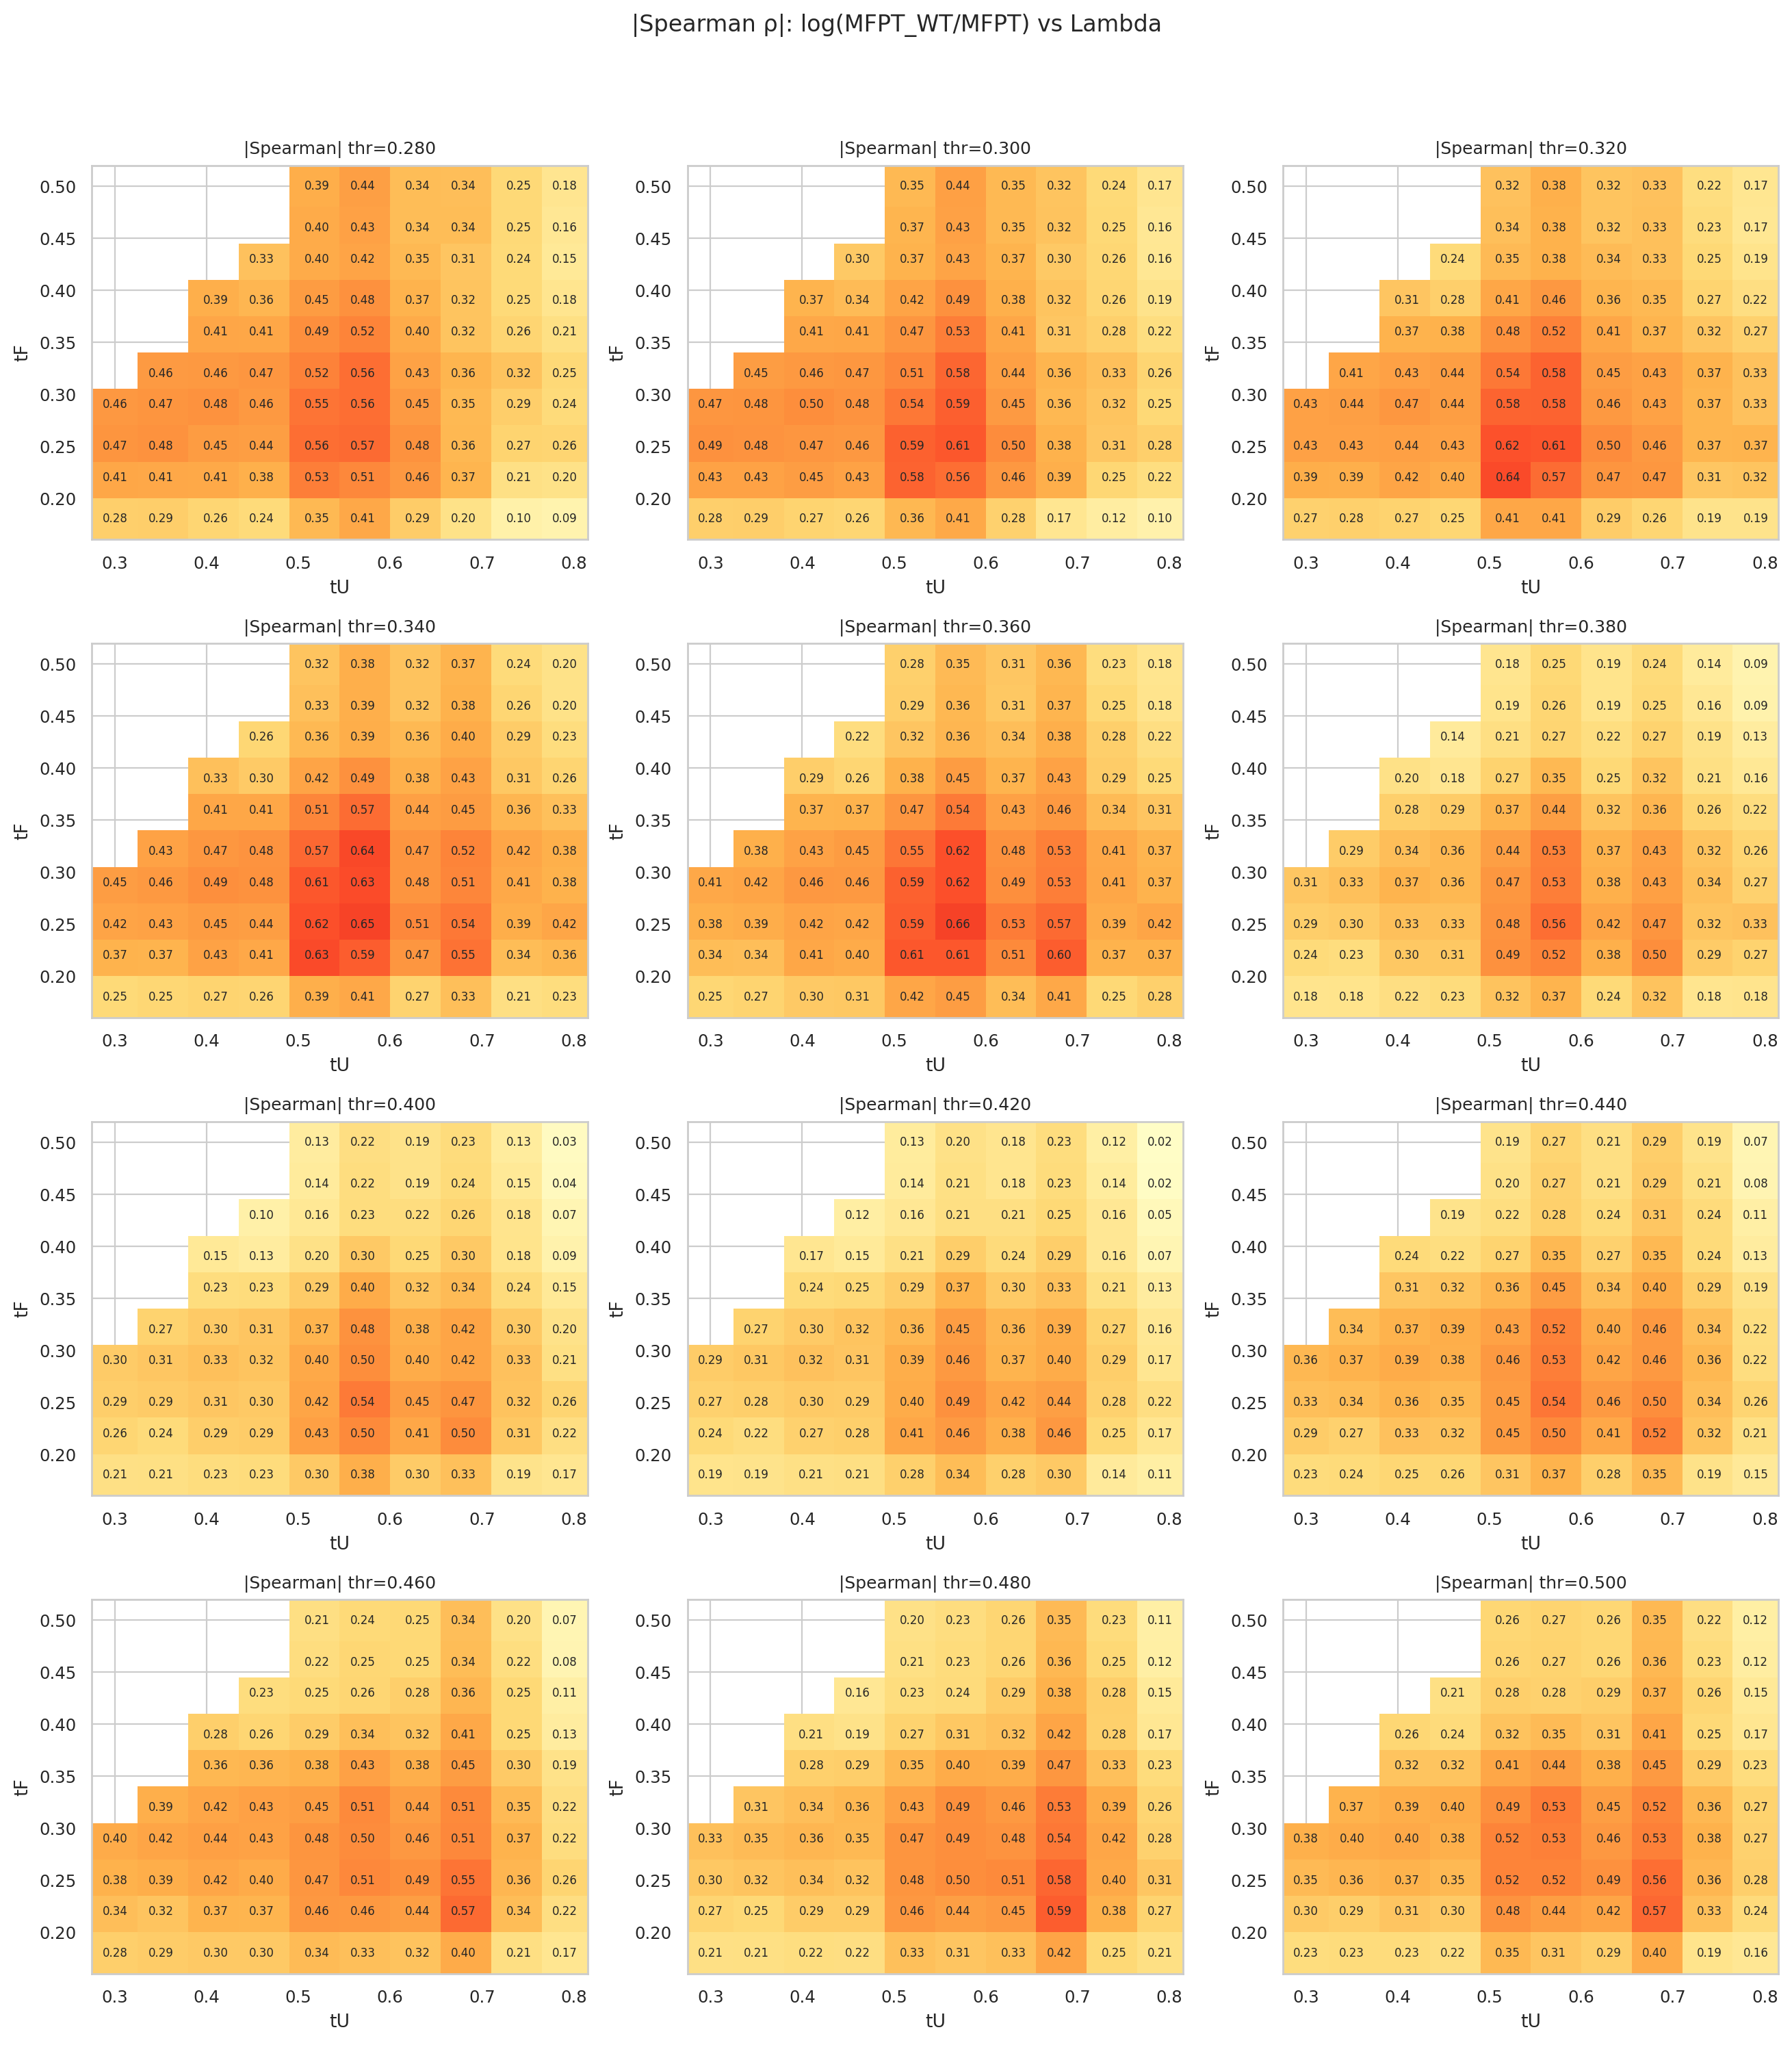

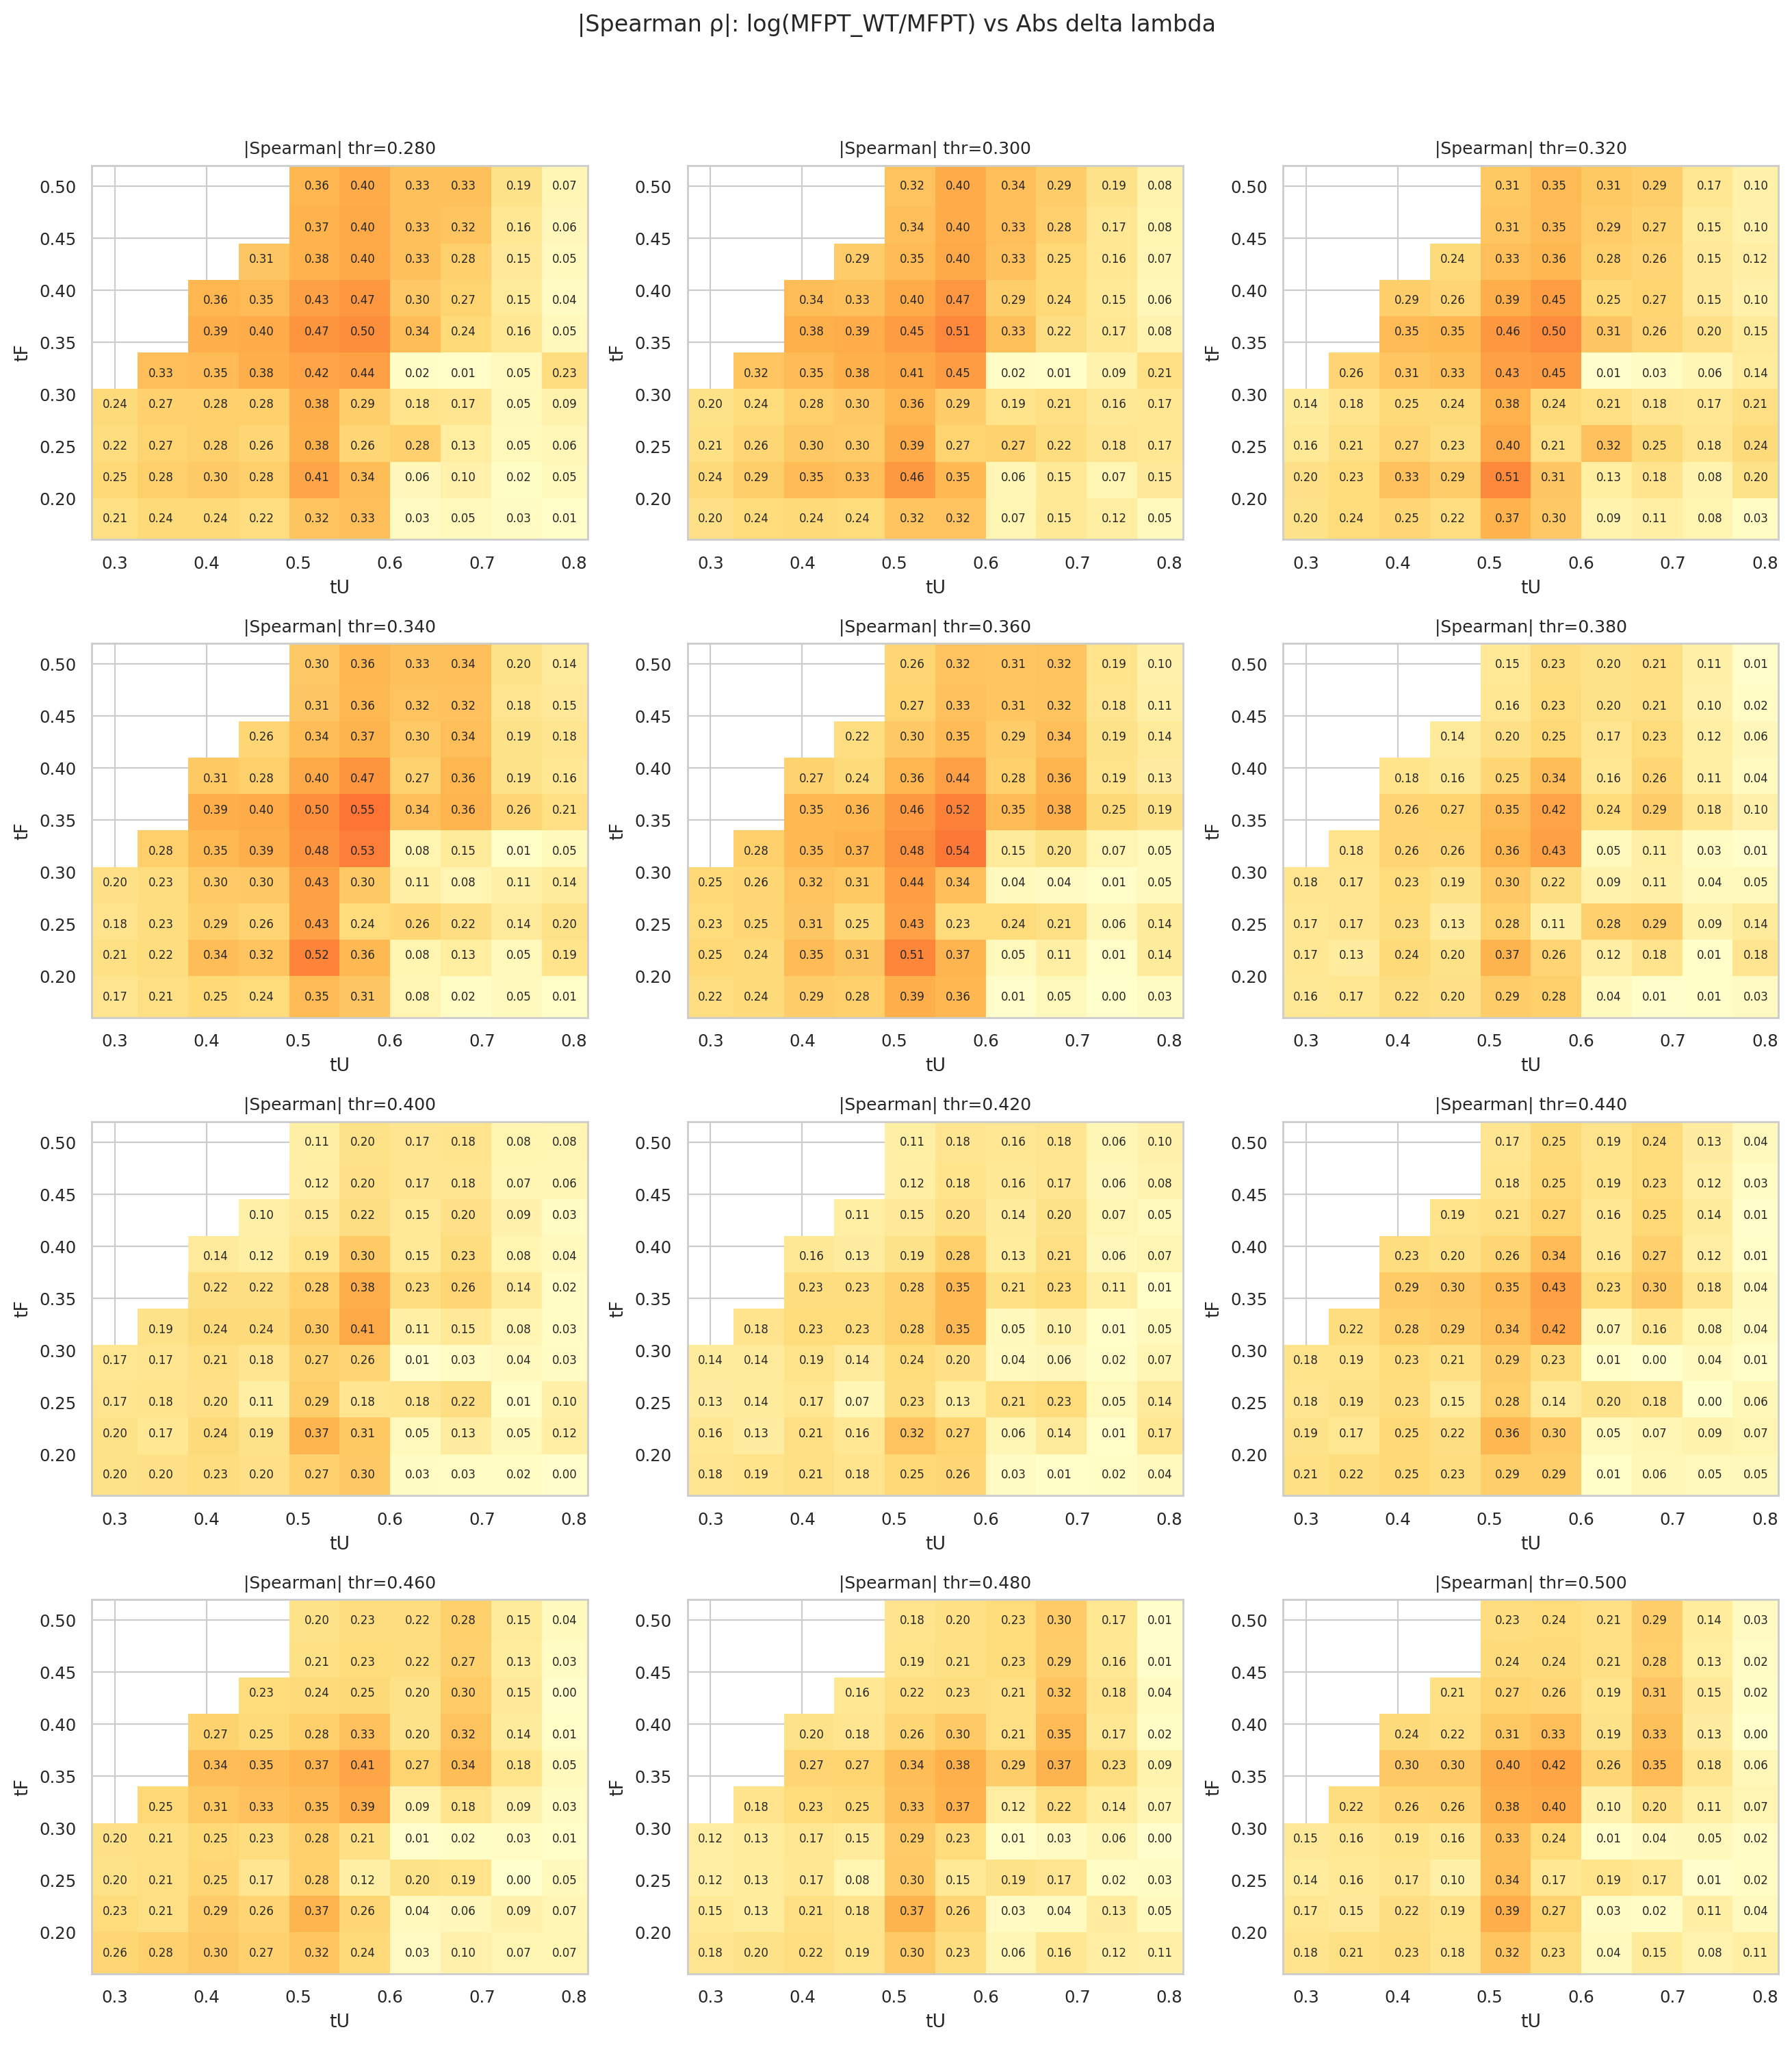

In [8]:
for metric_key, metric_label in metrics:
    results = heatmap_cache[metric_key]
    ncols = min(3, len(results) if results else 1)
    nrows = int(np.ceil(len(results) / ncols)) if results else 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)
    for ax, res in zip(axes.ravel(), results):
        df = pd.DataFrame(res['rows'])
        if df.empty:
            ax.axis('off')
            continue
        plot_heatmap_in_ax(ax, df, 'val', title=f"|Spearman| thr={res['thr']:.3f}", vmin=0, vmax=1)
    for ax in axes.ravel()[len(results):]:
        ax.axis('off')
    fig.suptitle(f"|Spearman ρ|: log(MFPT_WT/MFPT) vs {metric_label}", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


thr=0.36, tF=0.25, tU=0.57 | rho=0.66, r=0.68, p=7.8e-06


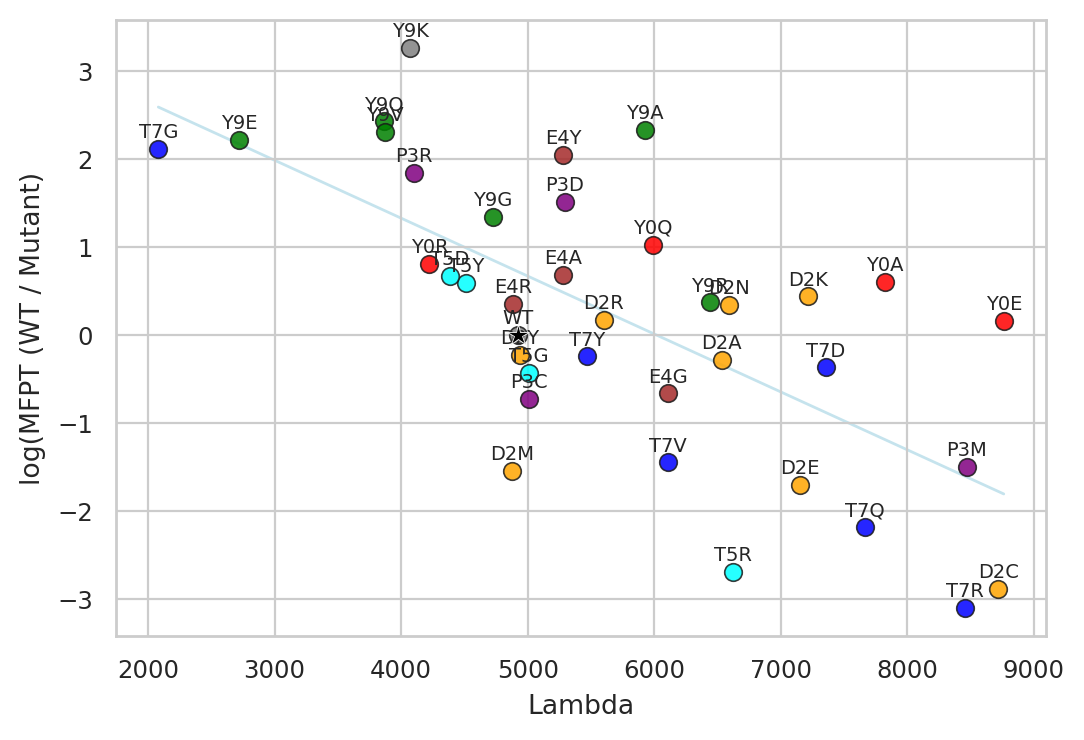

thr=0.36, tF=0.32, tU=0.57 | rho=0.54, r=0.56, p=0.00046


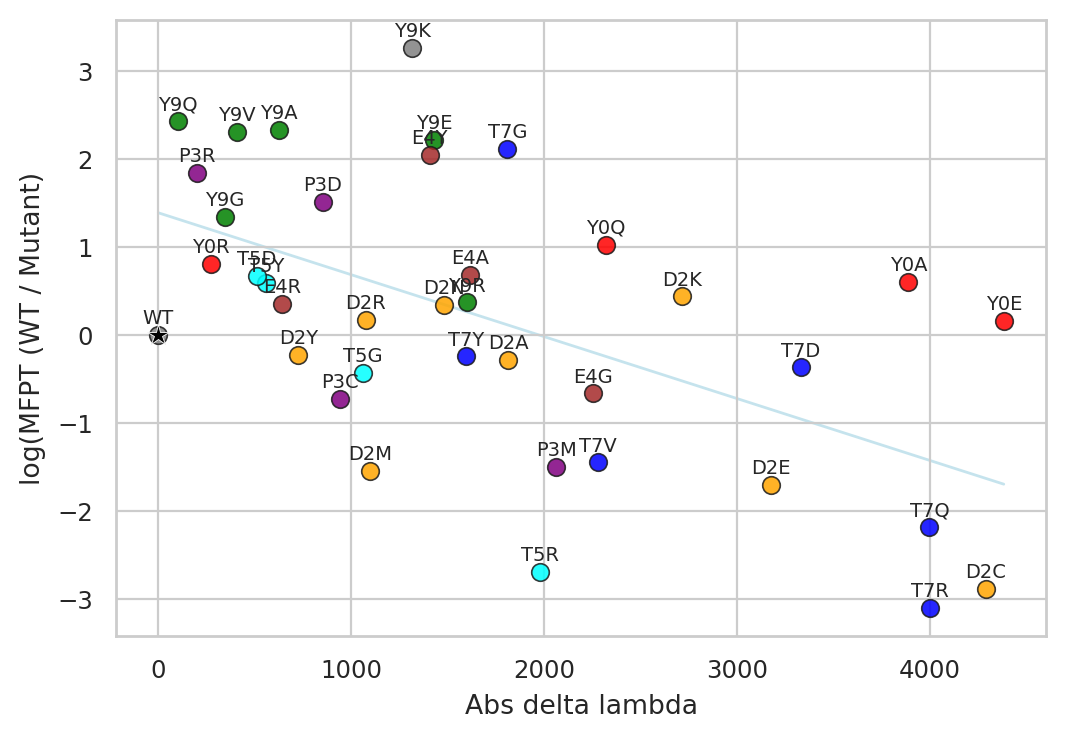

In [9]:
from common.consts import res_colors

for metric_key, metric_label in metrics:
    row = best_df.loc[best_df['metric'] == metric_key].iloc[0]
    df = best_cache[metric_key]
    fig, ax = plt.subplots(figsize=(6, 4))
    scatter_with_labels(
        ax,
        df,
        metric_key,
        'log_mfpt_ratio',
        label_col=None,
        color_col='residue_idx',
        colors=res_colors,
        s=40
    )
    wt = df.loc['WT']
    ax.plot(
        wt[metric_key],
        wt['log_mfpt_ratio'],
        marker='*',
        markersize=8,
        color='black',
        markeredgecolor='white',
        markeredgewidth=0.3,
        zorder=5,
    )
    ax.set_xlabel(metric_label)
    ax.set_ylabel('log(MFPT (WT / Mutant)')
    print(
        f""
        f"thr={row['thr']:.3g}, tF={row['tF']:.2g}, tU={row['tU']:.2g} | "
        f"rho={row['rho']:.2g}, r={row['pear']:.2g}, p={row['rho_p']:.2g}"
    )
    
    # after scatter_with_labels(...)
    x = df[metric_key].values
    y = df['log_mfpt_ratio'].values

    # fit y = a x + b
    a, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    yy = a * xx + b

    ax.plot(
        xx, yy,
        color='lightblue',
        alpha=0.7,      # 70% opacity
        linewidth=1,
        zorder=-1,
    
    )
    plt.show()
